# STAT 207 Group Lab Assignment 3 - [10 total points]

## Manipulating and Combining Data to Answer Questions

<hr>

## <u>Lab Grading</u>:

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

grade this submission

If you said **my submission is under netID** above, we will not read any more of your lab submission.

If you said **grade this submission** above, who worked with you on this submission?  Write both their **names** and **netIDs**.  

Colin Richardson - colinhr3

## <u>Purpose</u>:
You should work in groups of 2-3 on this report (not working in groups without permission will result in a point deduction). The purpose of this group lab assignment is to adjust data to be able to answer questions and provide insights from the data.
<hr>

### Group Roles

Suggested and specified roles are provided below: 

#### Groups of 2

* **Driver**: This student will type the report.  While typing the report, you may be the one who is selecting the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  Specific ways to help may include: outlining the general steps needed to solve a question (providing the overview), locating examples within the course notes, and reviewing each line of code as it is typed.

#### Groups of 3

* **Driver**: This student will type the report.  They may also be the one to select the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  They may select the general approach to answering the question and/or a few steps to be completed along the way. 
* **Communicator**: This student will review the report (as it is typed) to ensure that it is clear and concise.  This student may also locate relevant examples within the course notes that may help complete the assignment.

<hr>

### Imports

In [118]:
#Run this
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()  

## Steam Data

Steam is the world's most popular PC Gaming hub. They have a massive catalog of games, with everything from AAA blockbusters to small indie titles.  You are a team of data scientists working for Steam, and you are responsible for completing analysis for a report that will go to the executives of Valve (the parent company for Steam). 

Unfortunately, the data were collected with a less than optimal structure.  The dataset is comprised of transactions within the Steam platform for a random sample of 500 steam users along with their purchase and game play behaviors.  It has the following columns:
* user_id,
* game_name,
* activity:
    - purchase: indicating that the user has *purchased* the corresponding game
    - play: indicating that the user has *played* the corresponding game (for at least some amount of time.) 
* hours_played_if_play:
    - if the row corresponds to a 'play' activity, this number represents the number of hours the user has played the game
    - if the row corresponds to a 'purchase' activity, this number is always a 1 (and means nothing... it's a placeholder).

Note that for each user-game combo, there will either be one row (if the game has only been purchased but not played) or two rows (if the game has been both purchased and played).

**The executives have tasked you with identifying the games that are played the most to help them with an upcoming advertising campaign.**

### 1. [0.5 point] Reading in the Data

Read in the steam_sample.csv file into a dataframe, being sure to read in missing data correctly.  Drop the observations with missing values.  *Hint:* you can return to Lab 2 Questions 1 & 2, where you performed these steps.

Also, separate the data into a purchase and a play data frame, for the purchase rows and the play rows, respectively (Question 4 of Lab 2).

In [119]:
df = pd.read_csv("steam_sample.csv", na_values = ['unknown', '', '?', '-9999', 'None', 'nan', 'NaN', None])
df

,user_id,game_name,activity,hours_played_if_play
0,308653033,Unturned,purchase,1.0
1,308653033,Unturned,play,0.6
2,308653033,theHunter,purchase,1.0
3,144004384,Dota 2,purchase,1.0
4,144004384,Dota 2,play,22.0
...,...,...,...,...
7801,99096740,SimCity 4 Deluxe,play,0.2
7802,99096740,BioShock Infinite Burial at Sea - Episode 2,purchase,1.0
7803,99096740,The Elder Scrolls V Skyrim - Dawnguard,purchase,1.0
7804,99096740,The Elder Scrolls V Skyrim - Dragonborn,purchase,1.0


In [120]:
df_cleaned = df.dropna()
df_cleaned

df_play = df_cleaned[df_cleaned['activity'] == 'play']
df_play

df_purchase = df_cleaned[df_cleaned['activity'] == 'purchase']
df_purchase

,user_id,game_name,activity,hours_played_if_play
0,308653033,Unturned,purchase,1.0
2,308653033,theHunter,purchase,1.0
3,144004384,Dota 2,purchase,1.0
5,54103616,Counter-Strike Global Offensive,purchase,1.0
7,54103616,Counter-Strike,purchase,1.0
...,...,...,...,...
7800,99096740,SimCity 4 Deluxe,purchase,1.0
7802,99096740,BioShock Infinite Burial at Sea - Episode 2,purchase,1.0
7803,99096740,The Elder Scrolls V Skyrim - Dawnguard,purchase,1.0
7804,99096740,The Elder Scrolls V Skyrim - Dragonborn,purchase,1.0


### 2. [3 points] Games as the Unit of Observation

In Lab 2, we calculated the proportion of purchased games that were played.  In Questions 2 and 3, we're going to explore this proportion for each game separately, to determine if we can identify games that are must-play games.

In Question 2, we will adjust the unit of observation in our data to the game and then calculate measures for each unit of observation.  In Question 3, we will then combine different measures for each of those games to answer our question of interest.

**a)** First, create a data frame with two variables: the game and the number of users that purchased each game.  Make sure that you clean your data frame so that it is easy to use.

In [121]:
df_count_purchase = pd.DataFrame(df_purchase['game_name'].value_counts().reset_index())
df_count_purchase

,game_name,count
0,Dota 2,197
1,Team Fortress 2,94
2,Counter-Strike Global Offensive,66
3,Unturned,54
4,Counter-Strike Source,50
...,...,...
1440,Edna & Harvey The Breakout,1
1441,Memoria,1
1442,The Dark Eye Chains of Satinav,1
1443,The Night of the Rabbit,1


**b)** From the data frame in **part a**, determine the number of distinct games that were purchased by the 500 random users.  Each game should be counted only once, regardless of how many users have purchased the game.  You will use this number later to check that all games are in your final data.

In [122]:
len(df_count_purchase['game_name'].unique())

1445

**c)** Then, create a data frame that calculates the number of users that played each game.  Again, make sure that you clean your data frame.

In [123]:
df_count_play = pd.DataFrame(df_play['game_name'].value_counts().reset_index())
df_count_play

,game_name,count
0,Dota 2,197
1,Team Fortress 2,94
2,Counter-Strike Global Offensive,62
3,Unturned,43
4,Counter-Strike Source,37
...,...,...
915,Total Annihilation,1
916,Guilty Gear X2 #Reload,1
917,Cubemen,1
918,Towns,1


**d)** From the data frame in **part c**, determine the number of distinct games that were played by the 500 random users.  Again, each game should be counted only once, regardless of how many users have purchased the game.  

Does this number match the games calculated in **part b**?  Do these numbers seem plausible?

In [124]:
len(df_count_play['game_name'].unique())

920

No it does not match the games calculated in part b. The numbers are plausible because not all people who purchase games play them, which is why the number of games purchased is higher than the games played.

### 3. [3.5 points] What is the Purchase to Play Conversion for Steam Games?

Now that we have our two variables of interest calculated, we can combine the measures and to answer how many games are must-play games.

**a)** Merge your data frames from **parts a and c**, being sure that you retain any observation that appears in at least one of the two data frames.  *Hint*: Look up the pandas merge function, looking at the `how` parameter (input) in particular.  Try a few options for the `how` parameter.  Check the dimensions of the resulting data frame to see if you achieve the desired results.

In [125]:
df_merged = df_count_purchase.merge(df_count_play, how='inner')
df_merged

,game_name,count
0,Dota 2,197
1,Team Fortress 2,94
2,Borderlands 2,20
3,DayZ,15
4,Rust,15
...,...,...
515,Total Annihilation,1
516,Soldier Front 2,1
517,Screencheat,1
518,Need for Speed SHIFT,1


**b)** Calculate a new variable in the data for the number of users who have played that game divided by the number of users who have purchased the game (once for each distinct game).  

In [126]:
df_merged['proportion'] = df_count_play['count']/df_count_purchase['count']
df_merged

,game_name,count,proportion
0,Dota 2,197,1.000000
1,Team Fortress 2,94,1.000000
2,Borderlands 2,20,0.939394
3,DayZ,15,0.796296
4,Rust,15,0.740000
...,...,...,...
515,Total Annihilation,1,0.500000
516,Soldier Front 2,1,0.500000
517,Screencheat,1,0.500000
518,Need for Speed SHIFT,1,0.500000


**c)** What proportion of games in the data have a purchase to play conversion rate of 1 (that is every user who purchases the game also plays the game), or are must-play games?

In [127]:
df_merged[df_merged['proportion'] == 1]

,game_name,count,proportion
0,Dota 2,197,1.0
1,Team Fortress 2,94,1.0


In [128]:
2/520

0.0038461538461538464

The proportion is 2/520, or 0.0038461538461538464

### 4. [3 points] How Much Are Games Played?

In Questions 2 and 3, we used the purchase to play conversion to define must-play games.  Now, we will consider a different approach at defining whether a game is played the most: how long each game is played.  In other words, we might be looking to approximate how captivating a game is after it is opened by recording how long a user plays the game.

**a)** Create a variable for the median time spent playing a game, using a game as the unit of observation.  Prepare and clean it appropriately.

In [141]:
df_median_play = pd.DataFrame(df_play.groupby('game_name')['hours_played_if_play'].median().reset_index())
df_median_play

,game_name,hours_played_if_play
0,1... 2... 3... KICK IT! (Drop That Beat Like a...,0.2
1,18 Wheels of Steel American Long Haul,5.8
2,3DMark,1.3
3,60 Seconds!,1.6
4,7 Days to Die,27.0
...,...,...
915,Zombies Monsters Robots,19.0
916,hocus,0.1
917,oO,0.2
918,sZone-Online,0.8


**b)** Summarize the values for this variable, either with a visualization or numerical summaries.  There are multiple appropriate approaches that you could use.

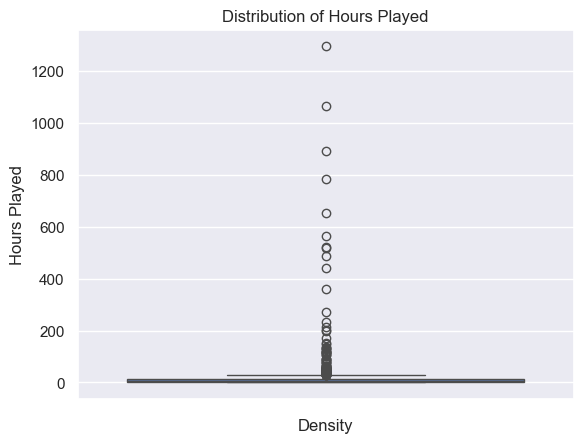

In [142]:
plt.figure()
sns.boxplot(df_median_play['hours_played_if_play'])
plt.title('Distribution of Hours Played')
plt.xlabel('Density')
plt.ylabel('Hours Played')
plt.show()

**c)** If the executives are looking for a threshold for especially captivating games (games where users typically play the game for an especially long period of time), what cutoff would you suggest?  You may be able to answer this question from part **b**, and you can also perform any additional analyses that you'd like.

We would suggest a cutoff of 250 hours, based off of the box plot we made showing less outliers above and around that value.